In [1]:
# Imports & Setup
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import warnings
import os

warnings.filterwarnings('ignore')

# Mount Drive
drive.mount('/content/drive', force_remount=False)

BASE_PATH = '/content/drive/MyDrive'
FEATURES_PATH = f'{BASE_PATH}/eye_tracking_features.csv'
OUTPUT_PATH  = f'{BASE_PATH}/eye_tracking_clean.csv'

print("Imports done")

Mounted at /content/drive
Imports done


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/eye_tracking_features.csv')
print(df.shape)
print(df.columns.tolist())
df.head(3)

(57, 38)
['right_fixation_count', 'right_fixation_rate', 'right_saccade_count', 'right_saccade_rate', 'right_blink_count', 'right_blink_rate', 'left_fixation_count', 'left_fixation_rate', 'left_saccade_count', 'left_saccade_rate', 'left_blink_count', 'left_blink_rate', 'tracking_ratio_mean', 'tracking_ratio_std', 'pupil_right_mean', 'pupil_right_std', 'pupil_right_missing_rate', 'pupil_left_mean', 'pupil_left_std', 'pupil_left_missing_rate', 'gaze_right_x_mean', 'gaze_right_x_std', 'gaze_right_y_mean', 'gaze_right_y_std', 'gaze_left_x_mean', 'gaze_left_x_std', 'gaze_left_y_mean', 'gaze_left_y_std', 'eye_pos_right_x_mean', 'eye_pos_right_y_mean', 'eye_pos_right_z_mean', 'eye_pos_left_x_mean', 'eye_pos_left_y_mean', 'eye_pos_left_z_mean', 'gaze_loss_rate_right', 'gaze_loss_rate_left', 'ParticipantID', 'Class']


,right_fixation_count,right_fixation_rate,right_saccade_count,right_saccade_rate,right_blink_count,right_blink_rate,left_fixation_count,left_fixation_rate,left_saccade_count,left_saccade_rate,...,eye_pos_right_x_mean,eye_pos_right_y_mean,eye_pos_right_z_mean,eye_pos_left_x_mean,eye_pos_left_y_mean,eye_pos_left_z_mean,gaze_loss_rate_right,gaze_loss_rate_left,ParticipantID,Class
0,6146,0.720431,914,0.107139,851,0.099754,6150,0.720900,921,0.107959,...,-40.337453,-45.658127,647.771259,10.631844,-43.041760,649.179194,0.004220,0.004220,1,ASD
1,8026,0.864033,664,0.071482,423,0.045538,8032,0.864679,664,0.071482,...,-53.040648,-97.163044,661.010382,0.985081,-87.687456,650.215914,0.003876,0.003876,10,ASD
2,9275,0.569123,1768,0.108486,4109,0.252132,5476,0.336013,974,0.059766,...,-45.035700,-12.368732,519.108330,0.533176,-5.165325,461.558990,0.003191,0.382034,11,ASD


In [4]:
# Load & Inspect
df = pd.read_csv(FEATURES_PATH)

feature_cols = [c for c in df.columns if c not in ['ParticipantID', 'Class']]

print(f"Shape: {df.shape}")
print(f"Feature columns ({len(feature_cols)}): {feature_cols}")
print(f"\nClass distribution:\n{df['Class'].value_counts()}")
print(f"\nMissing values:\n{df[feature_cols].isnull().sum()[df[feature_cols].isnull().sum() > 0]}")

Shape: (57, 38)
Feature columns (36): ['right_fixation_count', 'right_fixation_rate', 'right_saccade_count', 'right_saccade_rate', 'right_blink_count', 'right_blink_rate', 'left_fixation_count', 'left_fixation_rate', 'left_saccade_count', 'left_saccade_rate', 'left_blink_count', 'left_blink_rate', 'tracking_ratio_mean', 'tracking_ratio_std', 'pupil_right_mean', 'pupil_right_std', 'pupil_right_missing_rate', 'pupil_left_mean', 'pupil_left_std', 'pupil_left_missing_rate', 'gaze_right_x_mean', 'gaze_right_x_std', 'gaze_right_y_mean', 'gaze_right_y_std', 'gaze_left_x_mean', 'gaze_left_x_std', 'gaze_left_y_mean', 'gaze_left_y_std', 'eye_pos_right_x_mean', 'eye_pos_right_y_mean', 'eye_pos_right_z_mean', 'eye_pos_left_x_mean', 'eye_pos_left_y_mean', 'eye_pos_left_z_mean', 'gaze_loss_rate_right', 'gaze_loss_rate_left']

Class distribution:
Class
TD     30
ASD    27
Name: count, dtype: int64

Missing values:
pupil_left_mean        1
pupil_left_std         1
gaze_left_x_mean       1
gaze_left_x_

In [5]:
# Median Imputation
imputer = SimpleImputer(strategy='median')
df[feature_cols] = imputer.fit_transform(df[feature_cols])

print(f"Remaining nulls: {df[feature_cols].isnull().sum().sum()}")

Remaining nulls: 0


In [6]:
# Encode Class & Standard Scale
df['label'] = df['Class'].map({'ASD': 1, 'TD': 0})
df.head()

,right_fixation_count,right_fixation_rate,right_saccade_count,right_saccade_rate,right_blink_count,right_blink_rate,left_fixation_count,left_fixation_rate,left_saccade_count,left_saccade_rate,...,eye_pos_right_y_mean,eye_pos_right_z_mean,eye_pos_left_x_mean,eye_pos_left_y_mean,eye_pos_left_z_mean,gaze_loss_rate_right,gaze_loss_rate_left,ParticipantID,Class,label
0,6146.0,0.720431,914.0,0.107139,851.0,0.099754,6150.0,0.720900,921.0,0.107959,...,-45.658127,647.771259,10.631844,-43.041760,649.179194,0.004220,0.004220,1,ASD,1
1,8026.0,0.864033,664.0,0.071482,423.0,0.045538,8032.0,0.864679,664.0,0.071482,...,-97.163044,661.010382,0.985081,-87.687456,650.215914,0.003876,0.003876,10,ASD,1
2,9275.0,0.569123,1768.0,0.108486,4109.0,0.252132,5476.0,0.336013,974.0,0.059766,...,-12.368732,519.108330,0.533176,-5.165325,461.558990,0.003191,0.382034,11,ASD,1
3,9026.0,0.682186,1957.0,0.147910,1819.0,0.137480,9038.0,0.683093,1931.0,0.145945,...,-76.422091,580.736875,-7.854014,-76.856318,578.455563,0.004232,0.004232,13,ASD,1
4,9038.0,0.690609,1935.0,0.147857,1517.0,0.115917,9006.0,0.688164,1958.0,0.149614,...,-5.787664,607.015540,30.878989,-8.253471,613.500088,0.004355,0.004355,14,ASD,1


In [7]:
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])


print(f"Label distribution:\n{df_scaled['label'].value_counts()}")
print("\nScaling complete - preview of scaled features:")
print(df_scaled[feature_cols].describe().round(3))

Label distribution:
label
0    30
1    27
Name: count, dtype: int64

Scaling complete - preview of scaled features:
       right_fixation_count  right_fixation_rate  right_saccade_count  \
count                57.000               57.000               57.000   
mean                  0.000                0.000               -0.000   
std                   1.009                1.009                1.009   
min                  -1.194               -2.823               -1.056   
25%                  -0.631               -0.434               -0.772   
50%                  -0.394                0.325               -0.201   
75%                   0.523                0.683                0.339   
max                   3.478                1.350                4.317   

       right_saccade_rate  right_blink_count  right_blink_rate  \
count              57.000             57.000            57.000   
mean                0.000             -0.000             0.000   
std                 1.009   

In [8]:
df_scaled.head()

,right_fixation_count,right_fixation_rate,right_saccade_count,right_saccade_rate,right_blink_count,right_blink_rate,left_fixation_count,left_fixation_rate,left_saccade_count,left_saccade_rate,...,eye_pos_right_y_mean,eye_pos_right_z_mean,eye_pos_left_x_mean,eye_pos_left_y_mean,eye_pos_left_z_mean,gaze_loss_rate_right,gaze_loss_rate_left,ParticipantID,Class,label
0,-0.786818,0.312295,-0.838424,-0.173098,-0.699241,-0.410318,-0.766609,0.471039,-0.859465,-0.028147,...,-0.603124,0.838148,0.066620,-0.579347,0.906623,1.006059,-0.326030,1,ASD,1
1,-0.630679,1.020841,-0.963898,-0.944516,-0.795947,-0.773542,-0.597846,1.134147,-1.008364,-0.759057,...,-2.165511,0.939029,-0.254716,-2.011642,0.914587,0.695632,-0.328435,10,ASD,1
2,-0.526947,-0.434278,-0.409808,-0.143944,0.036901,0.610549,-0.827048,-1.304067,-0.828759,-0.993835,...,0.406700,-0.142252,-0.269769,0.635781,-0.534660,0.078314,2.313377,11,ASD,1
3,-0.547627,0.123587,-0.314951,0.708989,-0.480522,-0.157569,-0.507636,0.296670,-0.274298,0.733003,...,-1.536340,0.327352,-0.549147,-1.664164,0.363330,1.017400,-0.325942,13,ASD,1
4,-0.546630,0.165148,-0.325992,0.707830,-0.548759,-0.302035,-0.510506,0.320058,-0.258655,0.806521,...,0.606335,0.527593,0.741055,0.536709,0.632539,1.128267,-0.325083,14,ASD,1


In [9]:
# Mann-Whitney U Test
asd_mask = df_scaled['label'] == 1
td_mask  = df_scaled['label'] == 0

results = []
for col in feature_cols:
    asd_vals = df_scaled.loc[asd_mask, col]
    td_vals  = df_scaled.loc[td_mask,  col]
    stat, p  = stats.mannwhitneyu(asd_vals, td_vals, alternative='two-sided')
    results.append({'feature': col, 'p_value': round(p, 5), 'statistic': stat})

mw_df = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)

alpha = 0.05
selected_features = mw_df[mw_df['p_value'] < alpha]['feature'].tolist()

print(f"Total features: {len(feature_cols)}")
print(f"Significant (p < 0.05): {len(selected_features)}")
print(f"\nFull ranking:\n{mw_df.to_string(index=False)}")

Total features: 36
Significant (p < 0.05): 23

Full ranking:
                 feature  p_value  statistic
        gaze_right_y_std  0.00000      692.0
        right_blink_rate  0.00001      686.0
     tracking_ratio_mean  0.00001      119.0
         left_blink_rate  0.00001      691.0
         gaze_left_y_std  0.00001      684.0
         gaze_left_x_std  0.00002      670.0
     left_fixation_count  0.00003      144.0
     right_fixation_rate  0.00003      141.0
       gaze_right_x_mean  0.00003      142.0
        gaze_right_x_std  0.00003      669.0
        gaze_left_x_mean  0.00005      151.0
    right_fixation_count  0.00005      151.0
      left_fixation_rate  0.00033      180.0
        gaze_left_y_mean  0.00048      186.0
      tracking_ratio_std  0.00048      624.0
       gaze_right_y_mean  0.00151      206.0
    gaze_loss_rate_right  0.00412      585.0
    eye_pos_right_z_mean  0.00456      227.0
     eye_pos_left_z_mean  0.00613      233.0
      left_saccade_count  0.00643      

In [11]:

# Save clean scaled matrix
output_df = df_scaled[['ParticipantID', 'Class', 'label'] + feature_cols]
output_df.to_csv(OUTPUT_PATH, index=False)

# Save selected feature list
pd.Series(selected_features, name='selected_features').to_csv(
    f'{BASE_PATH}/selected_eye_features.csv', index=False
)

print(f" Clean matrix saved → {OUTPUT_PATH}")
print(f" Selected features saved → selected_eye_features.csv")
print(f"\nSelected features: {selected_features}")

 Clean matrix saved → /content/drive/MyDrive/eye_tracking_clean.csv
 Selected features saved → selected_eye_features.csv

Selected features: ['gaze_right_y_std', 'right_blink_rate', 'tracking_ratio_mean', 'left_blink_rate', 'gaze_left_y_std', 'gaze_left_x_std', 'left_fixation_count', 'right_fixation_rate', 'gaze_right_x_mean', 'gaze_right_x_std', 'gaze_left_x_mean', 'right_fixation_count', 'left_fixation_rate', 'gaze_left_y_mean', 'tracking_ratio_std', 'gaze_right_y_mean', 'gaze_loss_rate_right', 'eye_pos_right_z_mean', 'eye_pos_left_z_mean', 'left_saccade_count', 'right_saccade_count', 'left_blink_count', 'right_blink_count']


In [12]:
# updated alpha to 0.01
alpha = 0.01  # tightened from 0.05
selected_features = mw_df[mw_df['p_value'] < alpha]['feature'].tolist()

print(f"Total features: {len(feature_cols)}")
print(f"Significant (p < 0.01): {len(selected_features)}")
print(f"\nFull ranking:\n{mw_df.to_string(index=False)}")

Total features: 36
Significant (p < 0.01): 21

Full ranking:
                 feature  p_value  statistic
        gaze_right_y_std  0.00000      692.0
        right_blink_rate  0.00001      686.0
     tracking_ratio_mean  0.00001      119.0
         left_blink_rate  0.00001      691.0
         gaze_left_y_std  0.00001      684.0
         gaze_left_x_std  0.00002      670.0
     left_fixation_count  0.00003      144.0
     right_fixation_rate  0.00003      141.0
       gaze_right_x_mean  0.00003      142.0
        gaze_right_x_std  0.00003      669.0
        gaze_left_x_mean  0.00005      151.0
    right_fixation_count  0.00005      151.0
      left_fixation_rate  0.00033      180.0
        gaze_left_y_mean  0.00048      186.0
      tracking_ratio_std  0.00048      624.0
       gaze_right_y_mean  0.00151      206.0
    gaze_loss_rate_right  0.00412      585.0
    eye_pos_right_z_mean  0.00456      227.0
     eye_pos_left_z_mean  0.00613      233.0
      left_saccade_count  0.00643      

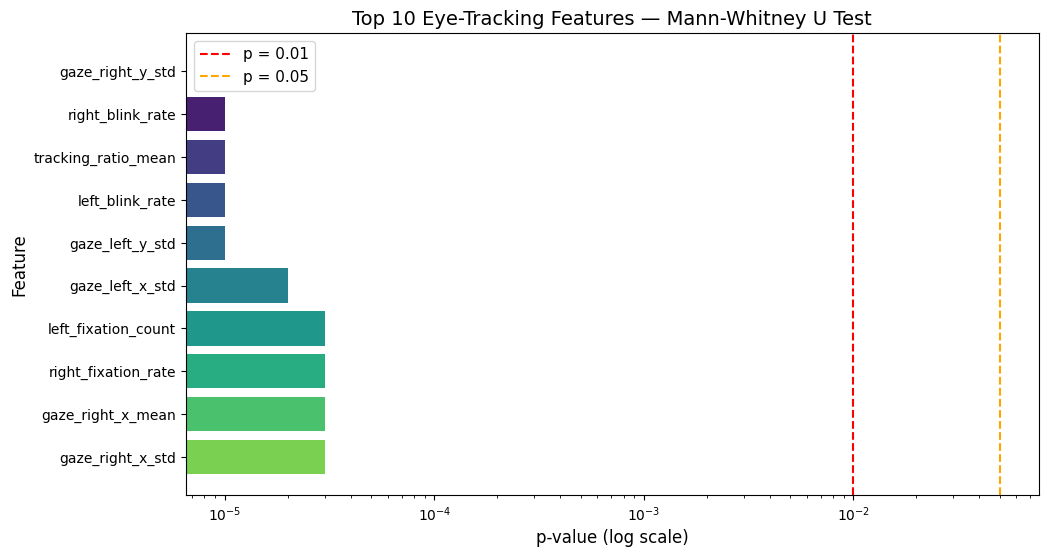

In [15]:
# Plot (log scale) & Save
top10 = mw_df.head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10['feature'], top10['p_value'], color=plt.cm.viridis(
    np.linspace(0, 0.8, len(top10))))

ax.axvline(0.01, color='red',    linestyle='--', linewidth=1.5, label='p = 0.01')
ax.axvline(0.05, color='orange', linestyle='--', linewidth=1.5, label='p = 0.05')
ax.set_xscale('log')
ax.set_xlabel('p-value (log scale)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Top 10 Eye-Tracking Features — Mann-Whitney U Test', fontsize=14)
ax.invert_yaxis()  # best feature at top
ax.legend(fontsize=11)


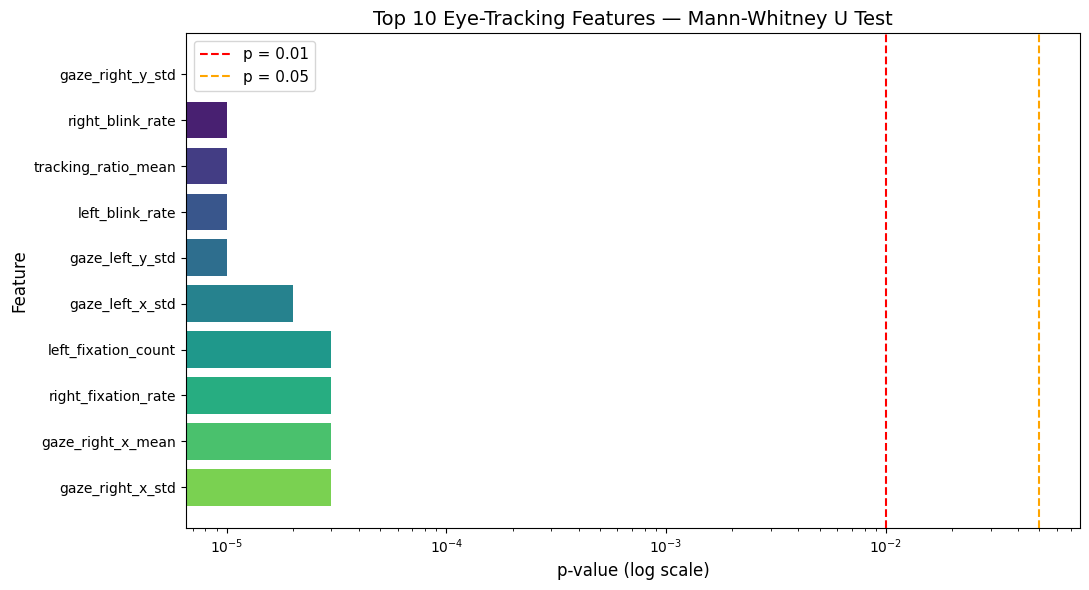

In [ ]:
# Plot (log scale) & Save
top10 = mw_df.head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10['feature'], top10['p_value'], color=plt.cm.viridis(
    np.linspace(0, 0.8, len(top10))))

ax.axvline(0.01, color='red',    linestyle='--', linewidth=1.5, label='p = 0.01')
ax.axvline(0.05, color='orange', linestyle='--', linewidth=1.5, label='p = 0.05')
ax.set_xscale('log')
ax.set_xlabel('p-value (log scale)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('Top 10 Eye-Tracking Features — Mann-Whitney U Test', fontsize=14)
ax.invert_yaxis()  # best feature at top
ax.legend(fontsize=11)


plt.tight_layout()
plt.savefig(f'{BASE_PATH}/mw_top10_features.png', dpi=150)
plt.show()


In [19]:
# Save clean matrix with only selected features
output_df = df_scaled[['ParticipantID', 'Class', 'label'] + selected_features]
output_df.to_csv(OUTPUT_PATH, index=False)

pd.Series(selected_features, name='selected_features').to_csv(
    f'{BASE_PATH}/selected_eye_features.csv', index=False
)

print(f"Clean matrix saved → {OUTPUT_PATH}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

Clean matrix saved → /content/drive/MyDrive/eye_tracking_clean.csv
Selected features (21): ['gaze_right_y_std', 'right_blink_rate', 'tracking_ratio_mean', 'left_blink_rate', 'gaze_left_y_std', 'gaze_left_x_std', 'left_fixation_count', 'right_fixation_rate', 'gaze_right_x_mean', 'gaze_right_x_std', 'gaze_left_x_mean', 'right_fixation_count', 'left_fixation_rate', 'gaze_left_y_mean', 'tracking_ratio_std', 'gaze_right_y_mean', 'gaze_loss_rate_right', 'eye_pos_right_z_mean', 'eye_pos_left_z_mean', 'left_saccade_count', 'right_saccade_count']



## Overview

This notebook covers the full preprocessing pipeline for the eye-tracking branch of the multimodal fusion model. The eye-tracking data is used **during training only** as a teacher signal — it is not required at inference time. The Streamlit app takes facial images only.

---

## Dataset Summary

| Property | Value |
|---|---|
| Source file | `/content/drive/MyDrive/eye_tracking_features.csv` |
| Shape | 57 participants × 38 columns |
| Feature columns | 36 engineered features |
| ID column | `ParticipantID` |
| Label column | `Class` (string: `ASD` / `TD`) |
| ASD participants | 27 |
| TD participants | 30 |

The 36 features cover: fixation counts/rates, saccade counts/rates, blink counts/rates (both eyes), tracking ratios, pupil metrics, gaze position (x/y), eye position (x/y/z), and gaze loss rates — for both left and right eyes.

---

## Step 1 — Missing Value Imputation

**Finding:** 9 missing values across 9 left-eye feature columns, all belonging to a single participant. The affected columns were: `pupil_left_mean`, `pupil_left_std`, `gaze_left_x_mean`, `gaze_left_x_std`, `gaze_left_y_mean`, `gaze_left_y_std`, `eye_pos_left_x_mean`, `eye_pos_left_y_mean`, `eye_pos_left_z_mean`.

**Method:** Median imputation via `sklearn.impute.SimpleImputer(strategy='median')`.

**Justification:** With only 57 participants, dropping the affected participant would meaningfully reduce our already small dataset. Mean imputation was ruled out because with n=57, a single outlier can skew the mean substantially. Median imputation is more robust to outliers and is the standard choice for small clinical datasets. Post-imputation null count: **0**.

---

## Step 2 — Label Encoding

**Mapping:** `ASD → 1`, `TD → 0`

**Justification:** The `Class` column contains string values. All downstream components — the neural network, loss functions, and statistical tests — require numeric labels. This is a standard binary classification encoding.

---

## Step 3 — Feature Scaling

**Method:** `sklearn.preprocessing.StandardScaler` — transforms each feature to mean=0, std=1.

**Justification:** The 36 features operate on very different scales. For example, fixation counts can reach into the hundreds while gaze loss rates sit between 0 and 1. Without scaling, features with larger magnitudes would dominate the neural network's weight updates and distort the Mann-Whitney rankings. StandardScaler ensures all features contribute on equal footing. Confirmed post-scaling: every feature shows `mean ≈ 0.000`, `std ≈ 1.009`.

---

## Step 4 — Feature Selection: Mann-Whitney U Test

**Method:** Non-parametric Mann-Whitney U test, comparing ASD vs TD distributions per feature. Threshold: **p < 0.01**.

**Why Mann-Whitney U (not a t-test)?**  
With n=57, normality of feature distributions cannot be assumed. The Mann-Whitney U test is non-parametric — it operates on ranks rather than raw values, making no assumptions about distribution shape. It tests whether ASD participants consistently score higher or lower than TD participants on a given feature, which is exactly the signal we need.

**Why p < 0.01 (not the standard p < 0.05)?**  
With 57 samples and 36 features, the feature-to-sample ratio is high (1:1.6), which creates a real risk of overfitting if we retain noise features. At p < 0.05, we accept up to a 5% chance that an observed group difference is random. Tightening to p < 0.01 reduces that to 1%, ensuring only features with strong, reliable signal enter the eye-tracking branch. Since the eye model acts as a **teacher** during fusion training, it needs to be built on clean, high-confidence signal.

**Results:**

| Threshold | Features retained | Features dropped |
|---|---|---|
| p < 0.05 | 23 | 13 |
| **p < 0.01 (chosen)** | **21** | **15** |

---

## Selected Features (21)

Ranked by p-value (ascending):

| Rank | Feature | p-value | Note |
|---|---|---|---|
| 1 | `gaze_right_y_std` | 0.00000 | Strongest discriminator |
| 2 | `right_blink_rate` | 0.00001 | Confirmed strong feature from EDA |
| 3 | `tracking_ratio_mean` | 0.00001 | Confirmed strong feature from EDA |
| 4 | `left_blink_rate` | 0.00001 | |
| 5 | `gaze_left_y_std` | 0.00001 | |
| 6 | `gaze_left_x_std` | 0.00002 | |
| 7 | `left_fixation_count` | 0.00003 | |
| 8 | `right_fixation_rate` | 0.00003 | |
| 9 | `gaze_right_x_mean` | 0.00003 | |
| 10 | `gaze_right_x_std` | 0.00003 | |
| 11 | `gaze_left_x_mean` | 0.00005 | |
| 12 | `right_fixation_count` | 0.00005 | |
| 13 | `left_fixation_rate` | 0.00033 | |
| 14 | `gaze_left_y_mean` | 0.00048 | |
| 15 | `tracking_ratio_std` | 0.00048 | |
| 16 | `gaze_right_y_mean` | 0.00151 | |
| 17 | `gaze_loss_rate_right` | 0.00412 | |
| 18 | `eye_pos_right_z_mean` | 0.00456 | |
| 19 | `eye_pos_left_z_mean` | 0.00613 | |
| 20 | `left_saccade_count` | 0.00643 | |
| 21 | `right_saccade_count` | 0.00856 | |

---

## Notable Findings

**`gaze_loss_rate_left` was not significant (p = 0.672).** This feature was flagged as strong during EDA based on visual inspection. The Mann-Whitney test contradicts that — there is no statistically significant difference between ASD and TD groups on this feature. The statistical test takes precedence. It was dropped.

**Gaze variability (std features) dominates the top rankings.** `gaze_right_y_std`, `gaze_left_y_std`, `gaze_left_x_std`, `gaze_right_x_std` all appear in the top 10. This suggests that inconsistency/variability in gaze patterns is more discriminative for ASD than mean gaze position — which is clinically consistent with known ASD gaze behaviour.

**Blink rate outperforms blink count.** `right_blink_rate` (p=0.00001) and `left_blink_rate` (p=0.00001) are far more discriminative than `right_blink_count` (p=0.023) and `left_blink_count` (p=0.018), both of which were dropped. Rate (normalised by time) is a better feature than raw count.

---

## Outputs Saved

| File | Location | Description |
|---|---|---|
| `eye_tracking_clean.csv` | `/content/drive/MyDrive/` | Scaled matrix, 57×24 (ParticipantID + Class + label + 21 features) |
| `selected_eye_features.csv` | `/content/drive/MyDrive/` | List of 21 selected feature names |
| `mw_top10_features.png` | `/content/drive/MyDrive/` | Log-scale bar chart of top 10 features by p-value |


## Eye tracking model

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Imports and configuration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

import joblib
import warnings
warnings.filterwarnings('ignore')

# Paths
MY_DRIVE    = '/content/drive/MyDrive'
EYE_CLEAN   = f'{MY_DRIVE}/eye_tracking_clean.csv'
FEATURES_LIST = f'{MY_DRIVE}/selected_eye_features.csv'
OUTPUT_DIR  = MY_DRIVE   # all outputs save here

# Reproducibility 
RANDOM_STATE = 42

print(" Imports complete")
print(f"   Eye features path : {EYE_CLEAN}")
print(f"   Output directory  : {OUTPUT_DIR}")

 Imports complete
   Eye features path : /content/drive/MyDrive/eye_tracking_clean.csv
   Output directory  : /content/drive/MyDrive


In [8]:
# Checking the processed data mathcing
eye_df = pd.read_csv('/content/drive/MyDrive/eye_tracking_clean.csv')
print(eye_df.shape)                    # Expected: (57, 24)
print(eye_df['Class'].value_counts())  # ASD: 27, TD: 30

(57, 24)
Class
TD     30
ASD    27
Name: count, dtype: int64


In [9]:
# Data loading and verification

eye_df = pd.read_csv(EYE_CLEAN)

# Load selected feature names
selected_features = pd.read_csv(FEATURES_LIST)['selected_features'].tolist()

# Separate components
X = eye_df[selected_features].values
y = eye_df['label'].values          # 0 = TD, 1 = ASD
participant_ids = eye_df['ParticipantID'].values

# Verification
print("=== Data Verification ===")
print(f"Full dataframe shape  : {eye_df.shape}        # Expected: (57, 24)")
print(f"Feature matrix shape  : {X.shape}             # Expected: (57, 21)")
print(f"Label array shape     : {y.shape}             # Expected: (57,)")
print(f"Null values in X      : {np.isnan(X).sum()}   # Expected: 0")
print(f"Null values in y      : {pd.isnull(y).sum()}  # Expected: 0")
print(f"Classes in y          : {np.unique(y)}        # Expected: [0 1]")
print(f"ASD (1) count         : {(y == 1).sum()}      # Expected: 27")
print(f"TD  (0) count         : {(y == 0).sum()}      # Expected: 30")
print(f"Features loaded       : {len(selected_features)}          # Expected: 21")
print(f"\nFeature list:\n{selected_features}")

=== Data Verification ===
Full dataframe shape  : (57, 24)        # Expected: (57, 24)
Feature matrix shape  : (57, 21)             # Expected: (57, 21)
Label array shape     : (57,)             # Expected: (57,)
Null values in X      : 0   # Expected: 0
Null values in y      : 0  # Expected: 0
Classes in y          : [0 1]        # Expected: [0 1]
ASD (1) count         : 27      # Expected: 27
TD  (0) count         : 30      # Expected: 30
Features loaded       : 21          # Expected: 21

Feature list:
['gaze_right_y_std', 'right_blink_rate', 'tracking_ratio_mean', 'left_blink_rate', 'gaze_left_y_std', 'gaze_left_x_std', 'left_fixation_count', 'right_fixation_rate', 'gaze_right_x_mean', 'gaze_right_x_std', 'gaze_left_x_mean', 'right_fixation_count', 'left_fixation_rate', 'gaze_left_y_mean', 'tracking_ratio_std', 'gaze_right_y_mean', 'gaze_loss_rate_right', 'eye_pos_right_z_mean', 'eye_pos_left_z_mean', 'left_saccade_count', 'right_saccade_count']


In [10]:
# Create your key here:
# env_content = "WANDB_API_KEY=your_actual_key_here"

# with open('/content/drive/MyDrive/.env', 'w') as f:
#     f.write(env_content)

# print("✅ .env saved to Drive")

In [11]:
# WandB authentication — run this before Cell 3

from dotenv import load_dotenv
import os

load_dotenv('/content/drive/MyDrive/.env')
WANDB_API_KEY = os.getenv('WANDB_API_KEY')

# Set as environment variable — WandB reads this automatically
os.environ["WANDB_API_KEY"] = WANDB_API_KEY

wandb.login(key=WANDB_API_KEY, relogin=False)
print(" WandB authenticated")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: mbaraka (mbaraka-carnegie-mellon-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


 WandB authenticated


In [12]:
# WandB initialisation and classifier definitions with search grids

wandb.init(
    project = "Multimodal-AI-Fusion-Project",
    name    = "eye-tracking-classifier",
    config  = {
        "n_participants"   : int(X.shape[0]),
        "n_features"       : int(X.shape[1]),
        "outer_cv_folds"   : 5,
        "inner_cv_folds"   : 3,
        "random_state"     : RANDOM_STATE,
        "asd_count"        : int((y == 1).sum()),
        "td_count"         : int((y == 0).sum()),
        "evaluation"       : "nested_stratified_cv",
        "primary_metric"   : "asd_recall",
        "classifiers"      : ["Random Forest", "XGBoost", "SVM"]
    }
)

# Classifier definitions with hyperparameter search grids
classifiers = {
    "Random Forest": {
        "model": RandomForestClassifier(
            class_weight = "balanced",
            random_state = RANDOM_STATE
        ),
        "grid": {
            "n_estimators" : [100, 300, 500],
            "max_depth"    : [3, 4, 5, None]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(
            scale_pos_weight = (y == 0).sum() / (y == 1).sum(),
            random_state     = RANDOM_STATE,
            eval_metric      = "logloss",
            verbosity        = 0
        ),
        "grid": {
            "n_estimators"  : [100, 200],
            "max_depth"     : [2, 3, 4],
            "learning_rate" : [0.01, 0.05, 0.1]
        }
    },
    "SVM": {
        "model": SVC(
            class_weight = "balanced",
            probability  = True,
            random_state = RANDOM_STATE
        ),
        "grid": {
            "C"      : [0.1, 1.0, 10.0],
            "kernel" : ["rbf", "linear"]
        }
    }
}

print("WandB run initialised")
print(f"\n Classifiers and search grids defined")
for name, clf in classifiers.items():
    n_combinations = 1
    for values in clf['grid'].values():
        n_combinations *= len(values)
    print(f"   {name}: {n_combinations} hyperparameter combinations")

WandB run initialised

 Classifiers and search grids defined
   Random Forest: 12 hyperparameter combinations
   XGBoost: 18 hyperparameter combinations
   SVM: 6 hyperparameter combinations


In [13]:
# Nested cross-validation loop

from sklearn.model_selection import GridSearchCV

# Outer loop — evaluates true generalisation performance
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Inner loop — finds best hyperparameters within each outer training fold
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Results container
results = {}

for clf_name, clf_config in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Running: {clf_name}")
    print(f"{'='*50}")

    fold_metrics = {
        "accuracy"  : [],
        "asd_recall": [],
        "asd_precision": [],
        "f1_asd"    : [],
        "roc_auc"   : [],
        "best_params": []
    }

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):

        # Split outer fold
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Inner loop — hyperparameter search on training fold only
        grid_search = GridSearchCV(
            estimator  = clf_config["model"],
            param_grid = clf_config["grid"],
            cv         = inner_cv,
            scoring    = "recall",      # optimise for ASD recall in inner loop
            n_jobs     = -1,
            refit      = True
        )
        grid_search.fit(X_train, y_train)

        # Best model evaluated on outer held-out fold
        best_model = grid_search.best_estimator_
        y_pred     = best_model.predict(X_test)
        y_prob     = best_model.predict_proba(X_test)[:, 1]

        # Compute fold metrics
        acc       = accuracy_score(y_test, y_pred)
        recall    = recall_score(y_test, y_pred, pos_label=1)
        precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
        f1        = f1_score(y_test, y_pred, pos_label=1)
        auc       = roc_auc_score(y_test, y_prob)

        fold_metrics["accuracy"].append(acc)
        fold_metrics["asd_recall"].append(recall)
        fold_metrics["asd_precision"].append(precision)
        fold_metrics["f1_asd"].append(f1)
        fold_metrics["roc_auc"].append(auc)
        fold_metrics["best_params"].append(grid_search.best_params_)

        print(f"  Fold {fold_idx+1} | Acc: {acc:.3f} | ASD Recall: {recall:.3f} "
              f"| F1: {f1:.3f} | AUC: {auc:.3f} | Params: {grid_search.best_params_}")

        # Log each fold to WandB
        wandb.log({
            f"{clf_name}/fold_{fold_idx+1}/accuracy"    : acc,
            f"{clf_name}/fold_{fold_idx+1}/asd_recall"  : recall,
            f"{clf_name}/fold_{fold_idx+1}/asd_precision": precision,
            f"{clf_name}/fold_{fold_idx+1}/f1_asd"      : f1,
            f"{clf_name}/fold_{fold_idx+1}/roc_auc"     : auc,
        })

    # Aggregate across folds
    results[clf_name] = {
        "mean_accuracy"      : np.mean(fold_metrics["accuracy"]),
        "std_accuracy"       : np.std(fold_metrics["accuracy"]),
        "mean_asd_recall"    : np.mean(fold_metrics["asd_recall"]),
        "std_asd_recall"     : np.std(fold_metrics["asd_recall"]),
        "mean_asd_precision" : np.mean(fold_metrics["asd_precision"]),
        "std_asd_precision"  : np.std(fold_metrics["asd_precision"]),
        "mean_f1_asd"        : np.mean(fold_metrics["f1_asd"]),
        "std_f1_asd"         : np.std(fold_metrics["f1_asd"]),
        "mean_roc_auc"       : np.mean(fold_metrics["roc_auc"]),
        "std_roc_auc"        : np.std(fold_metrics["roc_auc"]),
        "best_params_per_fold": fold_metrics["best_params"]
    }

    # Log aggregated results to WandB
    wandb.log({
        f"{clf_name}/mean_accuracy"   : results[clf_name]["mean_accuracy"],
        f"{clf_name}/mean_asd_recall" : results[clf_name]["mean_asd_recall"],
        f"{clf_name}/mean_f1_asd"     : results[clf_name]["mean_f1_asd"],
        f"{clf_name}/mean_roc_auc"    : results[clf_name]["mean_roc_auc"],
    })

    print(f"\n  SUMMARY — {clf_name}")
    print(f"  Accuracy  : {results[clf_name]['mean_accuracy']:.3f} ± {results[clf_name]['std_accuracy']:.3f}")
    print(f"  ASD Recall: {results[clf_name]['mean_asd_recall']:.3f} ± {results[clf_name]['std_asd_recall']:.3f}")
    print(f"  F1 (ASD)  : {results[clf_name]['mean_f1_asd']:.3f} ± {results[clf_name]['std_f1_asd']:.3f}")
    print(f"  ROC-AUC   : {results[clf_name]['mean_roc_auc']:.3f} ± {results[clf_name]['std_roc_auc']:.3f}")

print(f"\n Nested CV complete for all classifiers")


Running: Random Forest
  Fold 1 | Acc: 0.667 | ASD Recall: 0.667 | F1: 0.667 | AUC: 0.806 | Params: {'max_depth': 3, 'n_estimators': 100}
  Fold 2 | Acc: 0.917 | ASD Recall: 1.000 | F1: 0.923 | AUC: 1.000 | Params: {'max_depth': 5, 'n_estimators': 300}
  Fold 3 | Acc: 0.818 | ASD Recall: 0.600 | F1: 0.750 | AUC: 0.933 | Params: {'max_depth': 3, 'n_estimators': 100}
  Fold 4 | Acc: 1.000 | ASD Recall: 1.000 | F1: 1.000 | AUC: 1.000 | Params: {'max_depth': 3, 'n_estimators': 300}
  Fold 5 | Acc: 0.727 | ASD Recall: 0.800 | F1: 0.727 | AUC: 0.900 | Params: {'max_depth': 3, 'n_estimators': 100}

  SUMMARY — Random Forest
  Accuracy  : 0.826 ± 0.121
  ASD Recall: 0.813 ± 0.165
  F1 (ASD)  : 0.813 ± 0.126
  ROC-AUC   : 0.928 ± 0.072

Running: XGBoost
  Fold 1 | Acc: 0.667 | ASD Recall: 0.667 | F1: 0.667 | AUC: 0.736 | Params: {'learning_rate': 0.01, 'max_depth': 2, 'n_estimators': 100}
  Fold 2 | Acc: 1.000 | ASD Recall: 1.000 | F1: 1.000 | AUC: 1.000 | Params: {'learning_rate': 0.01, 'max_

In [14]:
# Final SVM retraining on full dataset

from sklearn.svm import SVC
import joblib

# The best hyperparameters were consistent across all 5 folds
# C=0.1, kernel=rbf selected in every single fold — high confidence selection
BEST_PARAMS = {"C": 0.1, "kernel": "rbf"}

print(f"Hyperparameters : {BEST_PARAMS}")
print(f"Training samples: {X.shape[0]}")
print(f"Features        : {X.shape[1]}")

# Instantiate final model with best hyperparameters
final_svm = SVC(
    C            = BEST_PARAMS["C"],
    kernel       = BEST_PARAMS["kernel"],
    class_weight = "balanced",
    probability  = True,
    random_state = RANDOM_STATE
)

# Train on all 57 participants
final_svm.fit(X, y)

# Verify training completed
train_preds = final_svm.predict(X)
train_acc   = accuracy_score(y, train_preds)

print(f"\nTraining accuracy (resubstitution): {train_acc:.3f}")

Hyperparameters : {'C': 0.1, 'kernel': 'rbf'}
Training samples: 57
Features        : 21

Training accuracy (resubstitution): 0.807


In [15]:
# Save model checkpoint
model_save_path = f"{OUTPUT_DIR}/best_eye_model.pkl"
joblib.dump(final_svm, model_save_path)
print(f"\n Model saved : {model_save_path}")

# Log final model config to WandB
wandb.log({
    "final_model/classifier"  : "SVM",
    "final_model/C"           : BEST_PARAMS["C"],
    "final_model/kernel"      : BEST_PARAMS["kernel"],
    "final_model/train_size"  : X.shape[0],
    "final_model/n_features"  : X.shape[1],
    "final_model/mean_cv_asd_recall" : results["SVM"]["mean_asd_recall"],
    "final_model/mean_cv_f1"         : results["SVM"]["mean_f1_asd"],
    "final_model/mean_cv_auc"        : results["SVM"]["mean_roc_auc"],
})

print(" Final model metrics logged to WandB")


 Model saved : /content/drive/MyDrive/best_eye_model.pkl
 Final model metrics logged to WandB


In [16]:
# Generate probability table for fusion notebook

# Generate probabilities from final SVM on all 57 participants
eye_probs = final_svm.predict_proba(X)   # shape (57, 2) — [prob_TD, prob_ASD]
eye_pred  = final_svm.predict(X)         # hard predictions for reference

# Build probability table
prob_table = pd.DataFrame({
    "ParticipantID"  : participant_ids,
    "true_label"     : y,                      # 0=TD, 1=ASD
    "true_class"     : eye_df["Class"].values, # ASD/TD string for readability
    "eye_prob_TD"    : eye_probs[:, 0],
    "eye_prob_ASD"   : eye_probs[:, 1],        # this is what fusion consumes
    "eye_pred"       : eye_pred
})

# Verification
print("=== Probability Table Verification ===")
print(f"Shape                    : {prob_table.shape}   # Expected: (57, 6)")
print(f"Null values              : {prob_table.isnull().sum().sum()}       # Expected: 0")
print(f"Probabilities sum to 1   : {(prob_table['eye_prob_TD'] + prob_table['eye_prob_ASD']).round(6).eq(1.0).all()}")
print(f"Prob range [0,1]         : min={prob_table['eye_prob_ASD'].min():.3f}, max={prob_table['eye_prob_ASD'].max():.3f}")
print(f"\nClass distribution in table:")
print(prob_table["true_class"].value_counts())

print(f"\nSample rows:")
print(prob_table.head(8).to_string(index=False))

=== Probability Table Verification ===
Shape                    : (57, 6)   # Expected: (57, 6)
Null values              : 0       # Expected: 0
Probabilities sum to 1   : True
Prob range [0,1]         : min=0.339, max=0.740

Class distribution in table:
true_class
TD     30
ASD    27
Name: count, dtype: int64

Sample rows:
 ParticipantID  true_label true_class  eye_prob_TD  eye_prob_ASD  eye_pred
             1           1        ASD     0.380448      0.619552         1
            10           1        ASD     0.580870      0.419130         0
            11           1        ASD     0.260283      0.739717         1
            13           1        ASD     0.350318      0.649682         1
            14           1        ASD     0.400107      0.599893         1
            15           1        ASD     0.271267      0.728733         1
            17           1        ASD     0.285685      0.714315         1
            18           1        ASD     0.318186      0.681814         1

In [17]:
# Save probability table
prob_table_path = f"{OUTPUT_DIR}/eye_tracking_probabilities.csv"
prob_table.to_csv(prob_table_path, index=False)
print(f"\n Probability table saved : {prob_table_path}")

# Log to WandB
wandb.log({
    "probability_table/n_participants" : len(prob_table),
    "probability_table/mean_asd_prob_for_asd"  : prob_table[prob_table["true_label"]==1]["eye_prob_ASD"].mean(),
    "probability_table/mean_asd_prob_for_td"   : prob_table[prob_table["true_label"]==0]["eye_prob_ASD"].mean(),
})

print(" Probability table metrics logged to WandB")


 Probability table saved : /content/drive/MyDrive/eye_tracking_probabilities.csv
 Probability table metrics logged to WandB


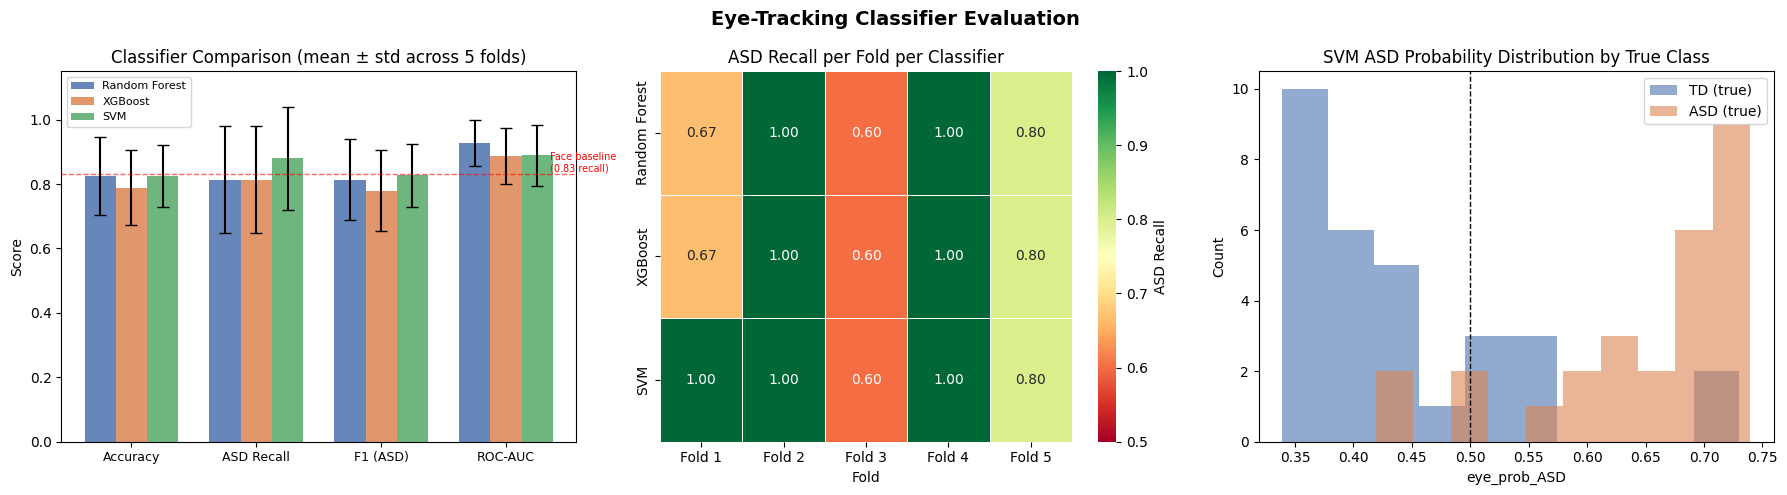

 Evaluation plot saved : /content/drive/MyDrive/eye_classifier_evaluation.png


In [19]:
# CEvaluation visualisations and close WandB run

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Eye-Tracking Classifier Evaluation", fontsize=14, fontweight="bold")

# Plot 1: Classifier comparison bar chart with error bars
clf_names  = list(results.keys())
metrics    = ["mean_accuracy", "mean_asd_recall", "mean_f1_asd", "mean_roc_auc"]
metric_labels = ["Accuracy", "ASD Recall", "F1 (ASD)", "ROC-AUC"]
colors     = ["#4C72B0", "#DD8452", "#55A868"]

x     = np.arange(len(metrics))
width = 0.25

for i, (clf_name, color) in enumerate(zip(clf_names, colors)):
    means  = [results[clf_name][m] for m in metrics]
    stds   = [results[clf_name][m.replace("mean", "std")] for m in metrics]
    bars   = axes[0].bar(x + i * width, means, width,
                         label=clf_name, color=color, alpha=0.85,
                         yerr=stds, capsize=4)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metric_labels, fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel("Score")
axes[0].set_title("Classifier Comparison (mean ± std across 5 folds)")
axes[0].legend(fontsize=8)
axes[0].axhline(y=0.83, color="red", linestyle="--", linewidth=1, alpha=0.6)
axes[0].text(3.6, 0.84, "Face baseline\n(0.83 recall)", fontsize=7, color="red")

# Plot 2: Per-fold ASD recall heatmap
fold_recall_data = {}
for clf_name, clf_config in classifiers.items():
    fold_recalls = []
    outer_cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    inner_cv_plot = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    for train_idx, test_idx in outer_cv_plot.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        gs = GridSearchCV(clf_config["model"], clf_config["grid"],
                         cv=inner_cv_plot, scoring="recall", n_jobs=-1, refit=True)
        gs.fit(X_tr, y_tr)
        fold_recalls.append(recall_score(y_te, gs.predict(X_te), pos_label=1))
    fold_recall_data[clf_name] = fold_recalls

heatmap_df = pd.DataFrame(fold_recall_data,
                           index=[f"Fold {i+1}" for i in range(5)]).T

sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0.5, vmax=1.0, ax=axes[1], linewidths=0.5,
            cbar_kws={"label": "ASD Recall"})
axes[1].set_title("ASD Recall per Fold per Classifier")
axes[1].set_xlabel("Fold")

# Plot 3: Eye probability distribution by true class
asd_probs = prob_table[prob_table["true_label"] == 1]["eye_prob_ASD"]
td_probs  = prob_table[prob_table["true_label"] == 0]["eye_prob_ASD"]

axes[2].hist(td_probs,  bins=10, alpha=0.6, color="#4C72B0", label="TD (true)")
axes[2].hist(asd_probs, bins=10, alpha=0.6, color="#DD8452", label="ASD (true)")
axes[2].axvline(x=0.5, color="black", linestyle="--", linewidth=1)
axes[2].set_xlabel("eye_prob_ASD")
axes[2].set_ylabel("Count")
axes[2].set_title("SVM ASD Probability Distribution by True Class")
axes[2].legend()

plt.tight_layout()
plot_path = f"{OUTPUT_DIR}/eye_classifier_evaluation.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f" Evaluation plot saved : {plot_path}")

In [20]:
# Log plot to WandB
wandb.log({"eye_classifier_evaluation": wandb.Image(plot_path)})

# Print final summary for dissertation reference
print("\n=== Final Summary for Dissertation ===")
print(f"Selected classifier : SVM (C=0.1, kernel=RBF)")
print(f"Selection criterion : Highest ASD recall with lowest variance")
print(f"ASD Recall          : {results['SVM']['mean_asd_recall']:.3f} ± {results['SVM']['std_asd_recall']:.3f}")
print(f"F1 (ASD)            : {results['SVM']['mean_f1_asd']:.3f} ± {results['SVM']['std_f1_asd']:.3f}")
print(f"Accuracy            : {results['SVM']['mean_accuracy']:.3f} ± {results['SVM']['std_accuracy']:.3f}")
print(f"ROC-AUC             : {results['SVM']['mean_roc_auc']:.3f} ± {results['SVM']['std_roc_auc']:.3f}")
print(f"Face baseline recall: 0.830")
print(f"Eye model recall    : {results['SVM']['mean_asd_recall']:.3f}")
print(f"Recall improvement  : +{results['SVM']['mean_asd_recall'] - 0.830:.3f} over face-only baseline")

# Close WandB run
wandb.finish()
print("\n WandB run closed")
print(" Notebook 03 complete")


=== Final Summary for Dissertation ===
Selected classifier : SVM (C=0.1, kernel=RBF)
Selection criterion : Highest ASD recall with lowest variance
ASD Recall          : 0.880 ± 0.160
F1 (ASD)            : 0.827 ± 0.097
Accuracy            : 0.826 ± 0.096
ROC-AUC             : 0.889 ± 0.095
Face baseline recall: 0.830
Eye model recall    : 0.880
Recall improvement  : +0.050 over face-only baseline


Random Forest/fold_1/accuracy,▁
Random Forest/fold_1/asd_precision,▁
Random Forest/fold_1/asd_recall,▁
Random Forest/fold_1/f1_asd,▁
Random Forest/fold_1/roc_auc,▁
Random Forest/fold_2/accuracy,▁
Random Forest/fold_2/asd_precision,▁
Random Forest/fold_2/asd_recall,▁
Random Forest/fold_2/f1_asd,▁
Random Forest/fold_2/roc_auc,▁
+86,...



 WandB run closed
 Notebook 03 complete
